## Setup: imports and database connection

In [1]:
import sys
sys.path.append("/Users/azadeh_sereshki/Documents/Projects/eicu-mortality-prediction/src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from db import get_engine

## Configure plots to look clean

In [3]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

engine = get_engine()
print("Ready to query.")

Ready to query.


## Load the cohort into pandas

In [4]:
# Pull the cohort view into a pandas DataFrame
cohort = pd.read_sql("SELECT * FROM cohort;", engine)
print(f"Cohort shape: {cohort.shape}")
print(f"Columns: {list(cohort.columns)[:8]}... (showing first 8 of {len(cohort.columns)})")
cohort.head()

Cohort shape: (1424, 30)
Columns: ['patientunitstayid', 'patienthealthsystemstayid', 'gender', 'age', 'ethnicity', 'hospitalid', 'wardid', 'apacheadmissiondx']... (showing first 8 of 30)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid,age_numeric
0,147784,134042,Female,60,Hispanic,67,109,Coma/change in level of consciousness (for hep...,154.9,05:06:00,...,1,admit,95.6,97.6,20:47:00,2381,Floor,Alive,002-10424,60
1,151179,136669,Female,59,Caucasian,66,90,"Sepsis, cutaneous/soft tissue",149.9,17:05:00,...,1,admit,NaN,73.0,02:50:00,4904,Floor,Alive,002-10079,59
2,151867,137216,Male,44,Caucasian,68,103,"GI perforation/rupture, surgery for",172.7,18:43:00,...,1,admit,NaN,84.1,06:18:00,1883,Floor,Alive,002-10323,44
3,151900,137239,Female,66,Caucasian,73,97,"Sepsis, pulmonary",165.1,10:02:00,...,1,admit,86.8,79.0,20:05:00,3460,Floor,Alive,002-10052,66
4,152954,138053,Female,41,Caucasian,71,87,"Respiratory - medical, other",170.2,01:56:00,...,1,admit,81.0,80.6,00:20:00,4224,Floor,Alive,002-10393,41


## Mortality by age group

  age_group  n_patients  deaths  mortality_pct
0       <40       165.0     3.0       1.818182
1     40-54       214.0    10.0       4.672897
2     55-69       429.0    26.0       6.060606
3     70-84       472.0    55.0      11.652542
4       85+       144.0    24.0      16.666667


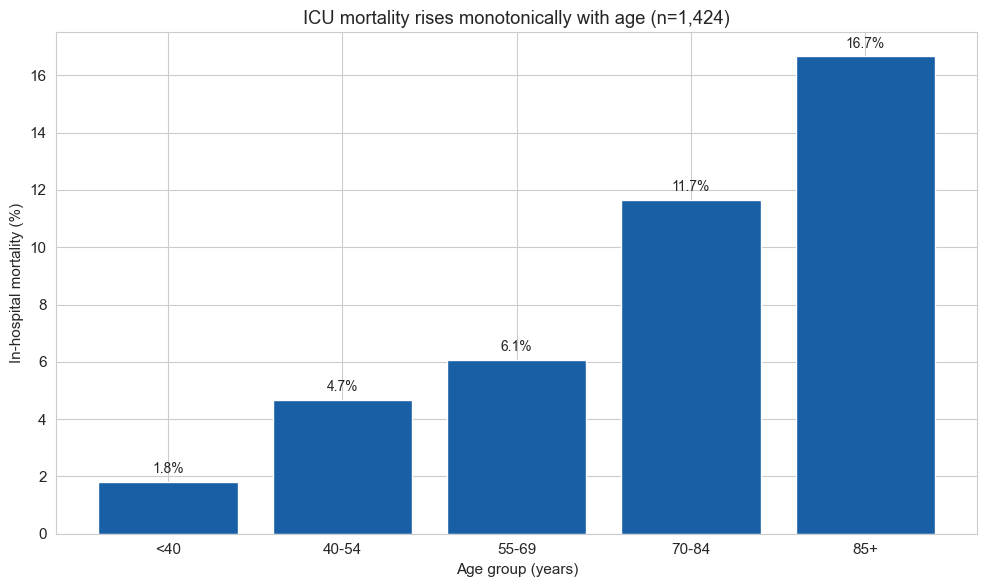

In [5]:
# Compute mortality rate by age group
age_bins = [0, 40, 55, 70, 85, 100]
age_labels = ["<40", "40-54", "55-69", "70-84", "85+"]
cohort["age_group"] = pd.cut(cohort["age_numeric"], bins=age_bins, labels=age_labels, right=False)

mortality_by_age = (
    cohort.groupby("age_group", observed=True)
    .apply(lambda g: pd.Series({
        "n_patients": len(g),
        "deaths": (g["hospitaldischargestatus"] == "Expired").sum(),
        "mortality_pct": 100.0 * (g["hospitaldischargestatus"] == "Expired").sum() / len(g),
    }))
    .reset_index()
)
print(mortality_by_age)

# Plot it
fig, ax = plt.subplots()
bars = ax.bar(mortality_by_age["age_group"].astype(str), mortality_by_age["mortality_pct"], color="#185FA5")
ax.set_ylabel("In-hospital mortality (%)")
ax.set_xlabel("Age group (years)")
ax.set_title("ICU mortality rises monotonically with age (n=1,424)")

# Annotate each bar with the mortality percentage
for bar, pct in zip(bars, mortality_by_age["mortality_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{pct:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Mortality by gender

   gender  n_patients  deaths  mortality_pct
0  Female       572.0    51.0       8.916084
1    Male       852.0    67.0       7.863850


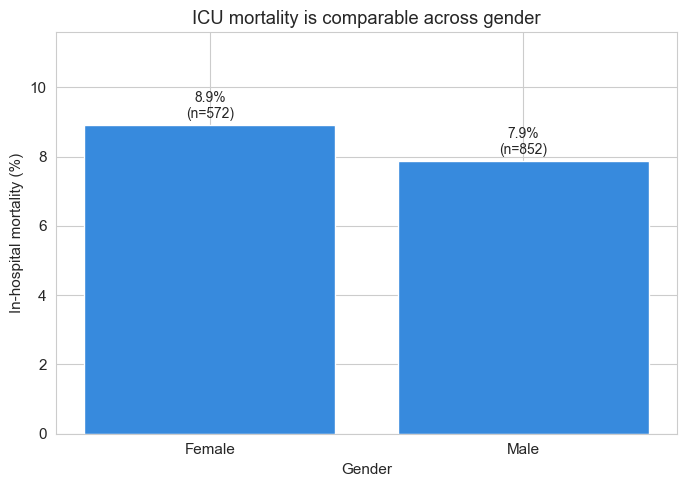

In [10]:
mortality_by_gender = (
    cohort.groupby("gender", observed=True)
    .apply(lambda g: pd.Series({
        "n_patients": len(g),
        "deaths": (g["hospitaldischargestatus"] == "Expired").sum(),
        "mortality_pct": 100.0 * (g["hospitaldischargestatus"] == "Expired").sum() / len(g),
    }))
    .reset_index()
)
# Keep only Male and Female (drop any missing/other)
mortality_by_gender = mortality_by_gender[mortality_by_gender["gender"].isin(["Male", "Female"])]
print(mortality_by_gender)

# Plot it
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(mortality_by_gender["gender"], mortality_by_gender["mortality_pct"],
              color="#378ADD")
ax.set_ylabel("In-hospital mortality (%)")
ax.set_xlabel("Gender")
ax.set_title("ICU mortality is comparable across gender")
ax.set_ylim(0, max(mortality_by_gender["mortality_pct"]) * 1.3)

# Annotate with N and percentage
for bar, row in zip(bars, mortality_by_gender.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{row.mortality_pct:.1f}%\n(n={int(row.n_patients)})",
            ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Apache chart

          apache_group  n_patients  deaths  mortality_pct
0         1. <30 (low)       152.0     2.0       1.315789
1  2. 30-59 (moderate)       608.0    25.0       4.111842
2      3. 60-89 (high)       330.0    38.0      11.515152
3   4. 90+ (very high)       100.0    37.0      37.000000
4        5. (no score)       234.0    16.0       6.837607


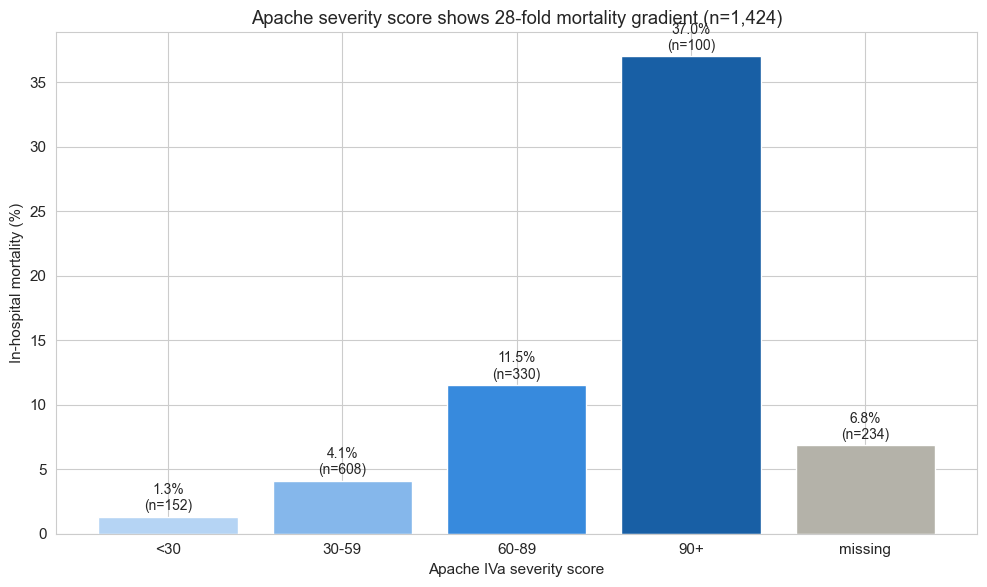

In [11]:
# Pull Apache IVa scores for cohort patients (requires JOIN with apachepatientresult)
apache_query = """
    SELECT 
        c.patientunitstayid,
        c.hospitaldischargestatus,
        a.apachescore
    FROM cohort c
    LEFT JOIN apachepatientresult a 
        ON c.patientunitstayid = a.patientunitstayid 
        AND a.apacheversion = 'IVa'
"""
cohort_with_apache = pd.read_sql(apache_query, engine)

# Categorize by Apache score
def apache_category(score):
    if pd.isna(score):
        return "5. (no score)"
    elif score < 30:
        return "1. <30 (low)"
    elif score < 60:
        return "2. 30-59 (moderate)"
    elif score < 90:
        return "3. 60-89 (high)"
    else:
        return "4. 90+ (very high)"

cohort_with_apache["apache_group"] = cohort_with_apache["apachescore"].apply(apache_category)

# Compute mortality by Apache group
mortality_by_apache = (
    cohort_with_apache.groupby("apache_group")
    .apply(lambda g: pd.Series({
        "n_patients": len(g),
        "deaths": (g["hospitaldischargestatus"] == "Expired").sum(),
        "mortality_pct": 100.0 * (g["hospitaldischargestatus"] == "Expired").sum() / len(g),
    }))
    .reset_index()
    .sort_values("apache_group")
)
print(mortality_by_apache)

# Plot — use a gradient from light to dark blue to convey increasing severity
colors = ["#B5D4F4", "#85B7EB", "#378ADD", "#185FA5", "#B4B2A9"]
clean_labels = ["<30", "30-59", "60-89", "90+", "missing"]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(clean_labels, mortality_by_apache["mortality_pct"], color=colors)
ax.set_ylabel("In-hospital mortality (%)")
ax.set_xlabel("Apache IVa severity score")
ax.set_title("Apache severity score shows 28-fold mortality gradient (n=1,424)")

# Annotate each bar
for bar, row in zip(bars, mortality_by_apache.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{row.mortality_pct:.1f}%\n(n={int(row.n_patients)})",
            ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Summary of findings

Three univariate predictors show meaningful mortality gradients in the cohort:

1. **Age** — monotonic 9-fold gradient from <40 (1.8%) to 85+ (16.7%)
2. **Gender** — comparable mortality across male and female patients (8.9% vs 7.9%)
3. **Apache IVa severity score** — 28-fold gradient from <30 (1.3%) to 90+ (37.0%); 16% of patients have missing scores, with mortality (6.8%) similar to the overall cohort mean

These findings inform feature selection for the mortality model. Age and Apache score will be included directly; Apache score missingness requires either imputation or reconstruction from component variables (vitals, labs, GCS).

The non-monotonic pattern of mortality across hospital bed categories (explored in `src/sql/04_cohort_characterization.sql`) motivates the cross-hospital generalization analysis planned for Week 4.